In [4]:
import pandas as pd
df = pd.read_csv("../data/processed/netflix_cleaned.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,tv show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International Tv Shows, Tv Dramas, Tv Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,tv show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime Tv Shows, International Tv Shows, Tv Act...",To protect his family from a powerful drug lor...
3,s4,tv show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality Tv","Feuds, flirtations and toilet talk go down amo..."
4,s5,tv show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International Tv Shows, Romantic Tv Shows, Tv ...",In a city of coaching centers known to train I...


In [5]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8807 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8807 non-null   str  
 9   duration      8807 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
df_model = df[['type','release_year','rating','duration','country']]

df_model.head()

,type,release_year,rating,duration,country
0,movie,2020,PG-13,90 min,United States
1,tv show,2021,TV-MA,2 Seasons,South Africa
2,tv show,2021,TV-MA,1 Season,Unknown
3,tv show,2021,TV-MA,1 Season,Unknown
4,tv show,2021,TV-MA,2 Seasons,India


In [7]:
df_model['duration'] = df_model['duration'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aashr\AppData\Local\Temp\ipykernel_22928\1917577388.py:1: SyntaxWarning: invalid escape sequence '\d'
  df_model['duration'] = df_model['duration'].str.extract('(\d+)').astype(float)


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_model['type'] = le.fit_transform(df_model['type'])
df_model['rating'] = le.fit_transform(df_model['rating'])
df_model['country'] = le.fit_transform(df_model['country'])

In [9]:
df_model.fillna(df_model.mean(), inplace=True)

,type,release_year,rating,duration,country
0,0,2020,8,90.0,603
1,1,2021,12,2.0,426
2,1,2021,12,1.0,736
3,1,2021,12,1.0,736
4,1,2021,12,2.0,251
...,...,...,...,...,...
8802,0,2007,9,158.0,603
8803,1,2018,15,2.0,736
8804,0,2009,9,88.0,603
8805,0,2006,7,88.0,603


In [10]:
from sklearn.cluster import KMeans

In [11]:
X = df_model[['release_year','duration','rating']]

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_model['cluster'] = kmeans.fit_predict(X)

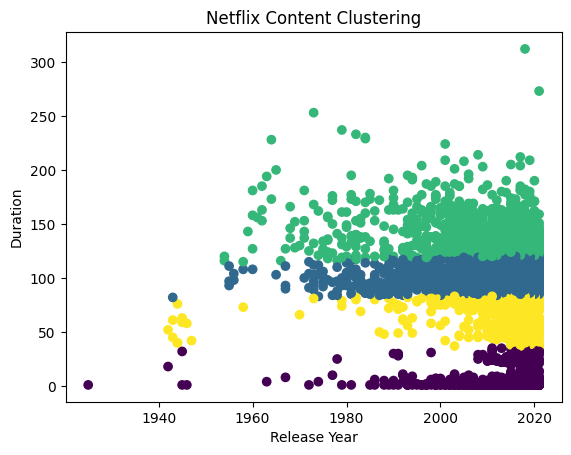

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df_model['release_year'], df_model['duration'], c=df_model['cluster'])
plt.xlabel("Release Year")
plt.ylabel("Duration")
plt.title("Netflix Content Clustering")
plt.show()

In [14]:
X = df_model[['release_year','duration','rating','country']]
y = df_model['type']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.9988649262202043


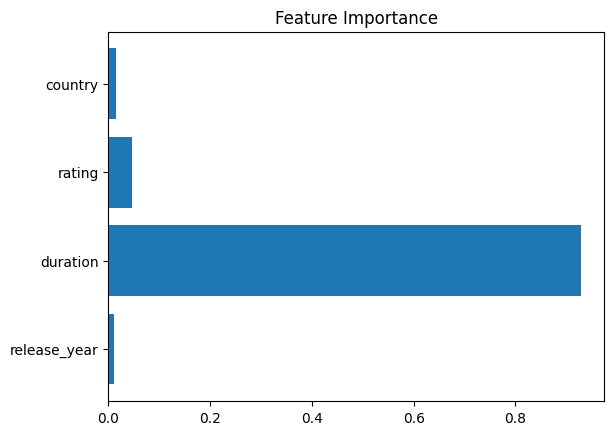

In [18]:
import numpy as np

importance = model.feature_importances_

features = X.columns

plt.barh(features, importance)

plt.title("Feature Importance")

plt.show()

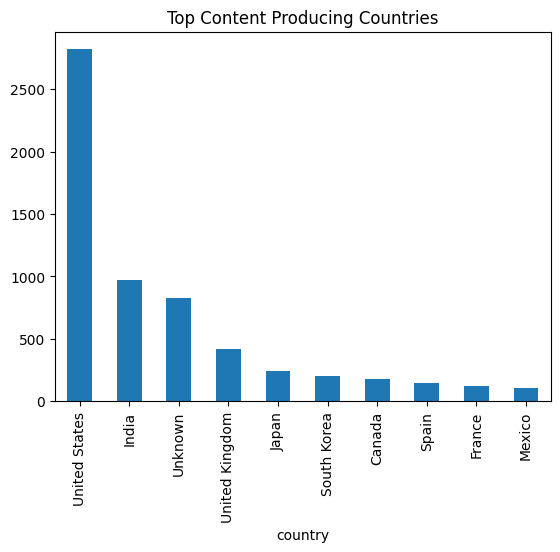

In [19]:
country_counts = df['country'].value_counts().head(10)

country_counts.plot(kind='bar')

plt.title("Top Content Producing Countries")

plt.show()

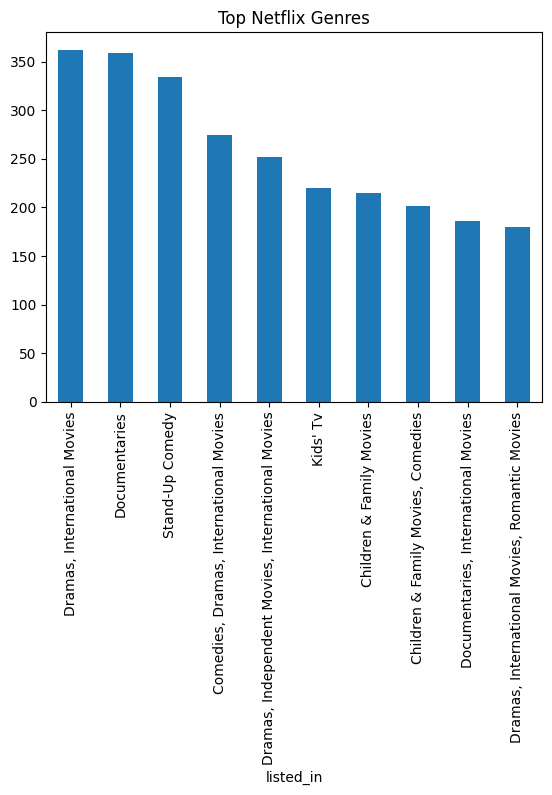

In [20]:
genre_counts = df['listed_in'].value_counts().head(10)

genre_counts.plot(kind='bar')

plt.title("Top Netflix Genres")

plt.show()

In [21]:
df_model.to_csv("netflix_model_data.csv", index=False)

In [22]:
df_model.groupby('cluster').mean()

,type,release_year,rating,duration,country
cluster,,,,,
0,0.945249,2016.552102,11.920523,2.997881,479.454256
1,0.000000,2013.781370,10.322466,100.003288,444.822466
2,0.000000,2009.049446,10.308610,139.595055,378.849957
3,0.000000,2014.838682,11.639202,67.560746,512.804857


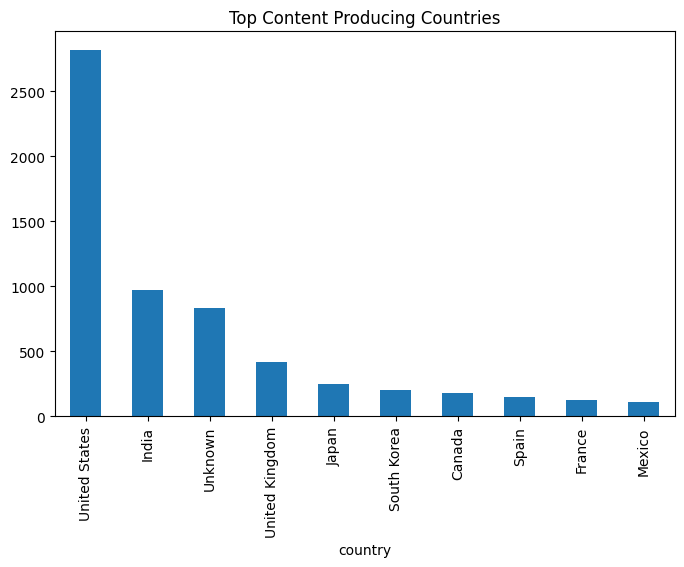

In [23]:
import matplotlib.pyplot as plt

top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar', figsize=(8,5), title="Top Content Producing Countries")

plt.show()

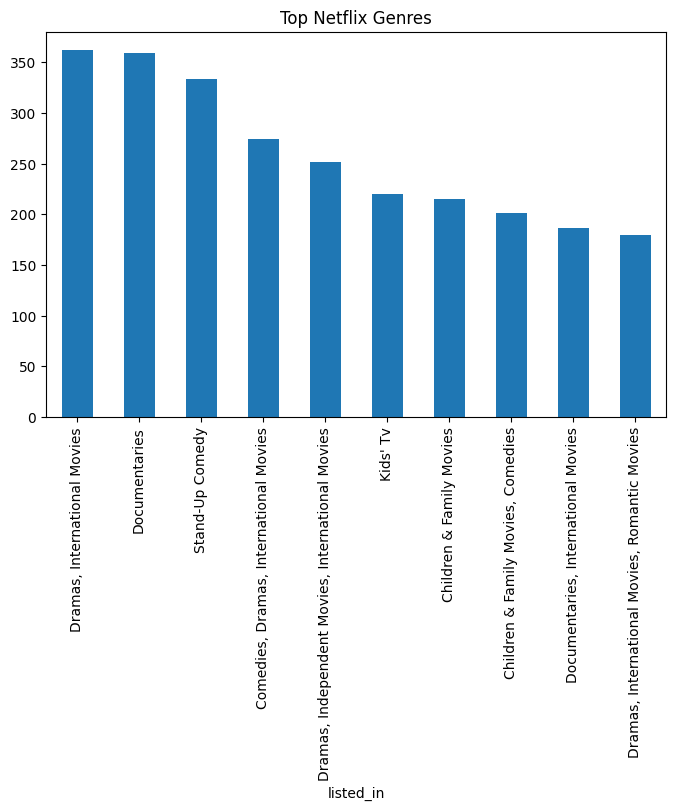

In [24]:
top_genres = df['listed_in'].value_counts().head(10)

top_genres.plot(kind='bar', figsize=(8,5), title="Top Netflix Genres")

plt.show()

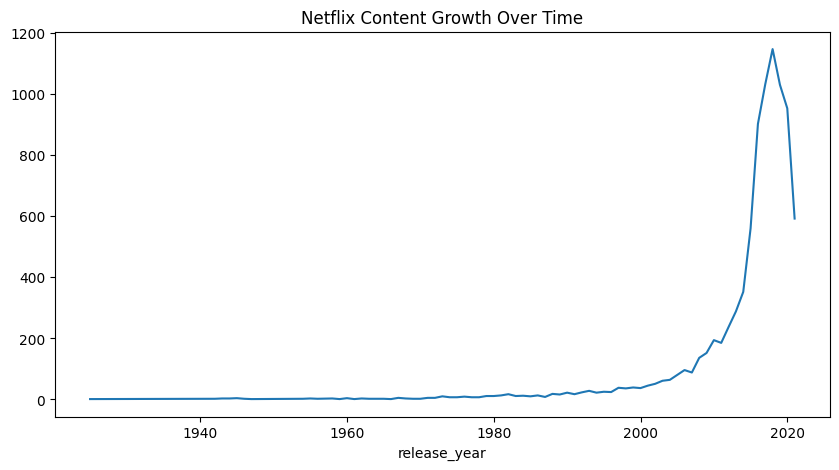

In [25]:
content_growth = df['release_year'].value_counts().sort_index()

content_growth.plot(figsize=(10,5), title="Netflix Content Growth Over Time")

plt.show()

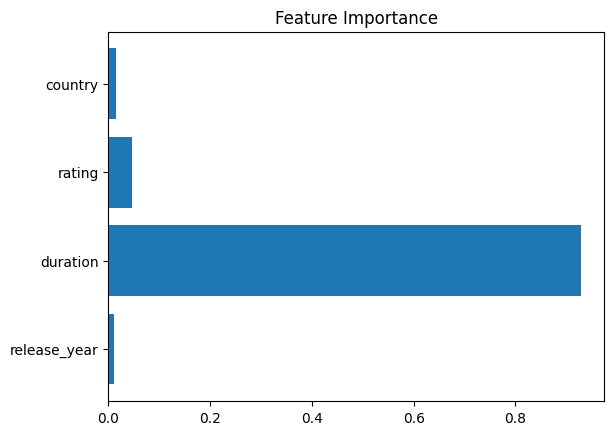

In [26]:
importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)

plt.title("Feature Importance")

plt.show()